## FBA Inventory Investigation Enhancement — #ItemIneligibleAR Contact Reduction A/B Testing Project

In [2]:
#import libraries

import pandas as pd
import numpy as np

#visualization

import matplotlib.pyplot as plt
import seaborn as sns

#Statistics

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest # two-proportion z-test


In [3]:
#Load Dataset

df = pd.read_csv(r'itemineligibleAR-ABtest/fba_item_ineligible_ar_ab_test.csv')


In [4]:
df.head()

,seller_id,marketplace,investigation_group,case_reopen_flag,reimbursement_outcome
0,A799K7936J1S,UK,control,1,rejected
1,A8Y8U4LZ32G00,ES,treatment,0,rejected
2,A054H872S8Y79,FR,treatment,0,rejected
3,A938793X70ITQ6,FR,treatment,0,approved
4,A3E7TQ2L33N801,DE,treatment,0,approved


In [9]:
print(df.shape)
print(df.size)

(1000, 5)
5000


In [12]:
# --- Quick Data Check ---

df.isnull().sum()

seller_id                0
marketplace              0
investigation_group      0
case_reopen_flag         0
reimbursement_outcome    0
dtype: int64

In [58]:
df.describe(include='all')

,seller_id,marketplace,investigation_group,case_reopen_flag,reimbursement_outcome
count,1000,1000,1000,1000.00000,1000
unique,1000,5,2,NaN,2
top,A799K7936J1S,DE,treatment,NaN,approved
freq,1,319,516,NaN,572
mean,NaN,NaN,NaN,0.23200,NaN
std,NaN,NaN,NaN,0.42232,NaN
min,NaN,NaN,NaN,0.00000,NaN
25%,NaN,NaN,NaN,0.00000,NaN
50%,NaN,NaN,NaN,0.00000,NaN
75%,NaN,NaN,NaN,0.00000,NaN


In [15]:
df.nunique()

seller_id                1000
marketplace                 5
investigation_group         2
case_reopen_flag            2
reimbursement_outcome       2
dtype: int64

In [17]:
df.dtypes

seller_id                object
marketplace              object
investigation_group      object
case_reopen_flag          int64
reimbursement_outcome    object
dtype: object

In [18]:
# --EDA-- Group Size

group_counts = df['investigation_group'].value_counts() #count sellers in each group

In [19]:
group_counts

investigation_group
treatment    516
control      484
Name: count, dtype: int64

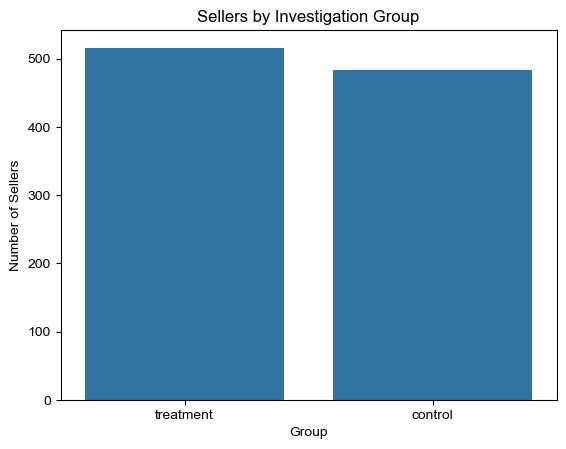

In [21]:
# Visualize the group

sns.barplot(x=group_counts.index, y=group_counts.values)

sns.set_theme(style="whitegrid")

plt.title("Sellers by Investigation Group")
plt.xlabel("Group")
plt.ylabel("Number of Sellers")
plt.show()

In [25]:
# --- EDA : Reopen Rate by Group ---

reopen_rate = df.groupby('investigation_group')['case_reopen_flag'].mean().reset_index()
reopen_rate.columns= ["group", "reopen_rate"]

In [26]:
reopen_rate

,group,reopen_rate
0,control,0.272727
1,treatment,0.193798


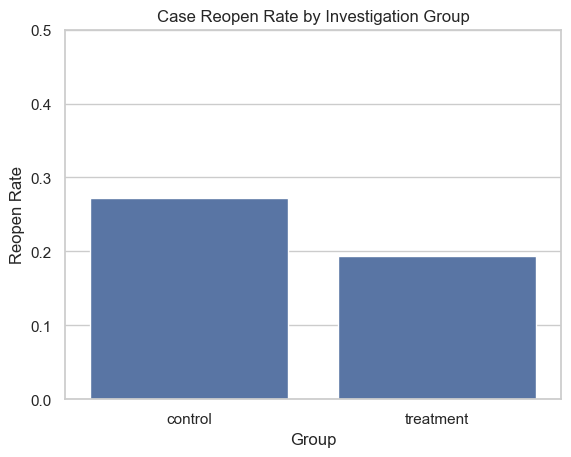

In [27]:
# -- Visualize the mean of two groups --
sns.barplot(x="group", y="reopen_rate", data=reopen_rate)  # visualize reopen rates
plt.title("Case Reopen Rate by Investigation Group")
plt.xlabel("Group")
plt.ylabel("Reopen Rate")
plt.ylim(0, 0.5)                                            # fix y-axis for clarity
plt.show()

## Observation

The EDA reveals a clear difference in case reopen rates between the two investigation groups:

- **Control group** (steps 1–4, no image evidence): **27.27%** reopen rate
- **Treatment group** (steps 1–5, with image/footage evidence): **19.38%** reopen rate
- **Observed reduction: ~7.9 percentage points**

**Control group** — sellers whose #ItemIneligibleAR cases were investigated using the existing process (steps 1–4 only: invoice, POD, shipment trend, weight comparison). No image or footage evidence was used. This represents the baseline — before the enhancement.

**Treatment group** — sellers whose cases were investigated using the enhanced process (steps 1–5, with image/footage evidence from the FC receiving dock added on top). This represents the after — with Kalyan's proposed improvement.

Sellers in the treatment group were less likely to reopen or escalate their case — 
suggesting that visual evidence from the FC receiving dock provided clearer closure, 
whether the reimbursement was approved or rejected.

However, this is purely an observed difference so far. 
We cannot conclude this reduction is real until we verify it is **statistically significant** 
— meaning it is unlikely to have occurred by chance.

In the next section, we will formally test this using a **Two-Proportion Z-Test**.

## Hypothesis Testing

We want to determine if the observed reduction in case reopen rate 
between the control and treatment group is statistically significant.

**Null Hypothesis (H0):**
There is no difference in case reopen rates between the control and treatment group.
The imaging feature had no effect.
p_control = p_treatment

**Alternative Hypothesis (H1):**
The treatment group has a significantly lower reopen rate than the control group.
The imaging feature reduced case reopens.
p_control > p_treatment

**Significance Level: α = 0.05**
If our p-value is less than 0.05 we reject H0 and conclude the reduction is statistically significant.

In [55]:
# -- Two Propotion Ztest -- Since we are handling propotions of reopened and closed case we use Ztest

# Isolate each group based on the control and treatment group
control_df = df[df['investigation_group']=='control']
treatment_df = df[df['investigation_group']=='treatment']

# number of reopens in each group
control_reopens = control_df['case_reopen_flag'].sum()
treatment_reopens = treatment_df['case_reopen_flag'].sum()

# total sellers in each group
n_control = len(control_df)
n_treatment = len(treatment_df)

# counts array and nobs array for proportions_ztest
counts = np.array([control_reopens, treatment_reopens])
nobs = np.array([n_control,n_treatment])

# run the two proportion z-test 
z_stat,p_value = proportions_ztest(counts,nobs,alternative='larger') # we say alternative = larger, expecting reopen rate of control is high

print(f"Control reopen rate   : {control_reopens/n_control:.4f}")
print(f"Treatment reopen rate : {treatment_reopens/n_treatment:.4f}")
print(f"Z-Statistic           : {z_stat:.4f}")
print(f"P-Value               : {p_value:.4f}")

Control reopen rate   : 0.2727
Treatment reopen rate : 0.1938
Z-Statistic           : 2.9550
P-Value               : 0.0016


In [56]:
# -- Effect Size --

# absolute reduction in reopen rate between control and treatment
effect_size = (control_reopens/n_control) - (treatment_reopens/n_treatment)  

print(f"Absolute Reduction in Reopen Rate : {effect_size:.4f}")
print(f"Relative Reduction                : {effect_size/(control_reopens/n_control)*100:.2f}%")

Absolute Reduction in Reopen Rate : 0.0789
Relative Reduction                : 28.94%


## Business Recommendation

### What did we test?
We ran an A/B test across EU marketplaces to evaluate whether adding image and footage 
evidence from the FC receiving dock (Step 5) as an additional investigation layer 
reduced the #ItemIneligibleAR case reopen rate compared to the existing process (Steps 1–4).

### What did the data tell us?

| Metric | Value |
|---|---|
| Control reopen rate (old process) | 27.27% |
| Treatment reopen rate (new process) | 19.38% |
| Absolute reduction | 7.89 percentage points |
| Relative reduction | 28.94% |
| Z-Statistic | 2.9550 |
| P-Value | 0.0016 |

### Conclusion
The reduction in case reopen rate is statistically significant (p = 0.0016 < α = 0.05).
The imaging feature did not just reduce reopens by chance — it delivered a genuine, 
measurable improvement in investigation quality.

### Why did it work?
Sellers reopened cases primarily because the existing process gave them no clear closure.
When image and footage evidence was introduced:
- Eligible sellers received reimbursement backed by visual proof — closing the case with trust
- Ineligible sellers were shown clear evidence of short shipment — removing grounds for escalation
- Either way, sellers had a definitive answer — reducing frustration and contact volume

### Recommendation
**Roll out the imaging investigation layer (Step 5) across all EU marketplaces.**

The data strongly supports that this enhancement:
- Reduces seller contact volume by ~29% relative to the old process
- Builds seller trust through transparent, evidence-based decisions
- Reduces load on account managers handling escalations